In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import statistics as sts 
import streamlit as st 
from matplotlib import pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler,LabelEncoder,PowerTransformer
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.linear_model import LogisticRegression,Lasso,ElasticNet,Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest,f_classif,f_regression
from sklearn.metrics import f1_score,classification_report,confusion_matrix,precision_score,recall_score

In [2]:
df1=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\machineLearning1\pred09\final_test.csv",encoding_errors='ignore')

In [3]:
df1.sample(10)

,weight,age,height,size
11111,72,29.0,170.18,XL
8901,54,27.0,167.64,S
111191,70,41.0,177.80,XXXL
2230,54,43.0,170.18,S
74540,65,31.0,177.80,M
27846,56,30.0,160.02,S
10463,68,29.0,175.26,XL
81222,68,30.0,175.26,M
101084,61,36.0,162.56,L
75056,72,34.0,165.10,XXXL


In [4]:
def basicOperations(df1):
    print(df1.ndim)
    print(df1.shape)
    print(df1.size)
    print(df1.describe())
    print(df1.info())
    print(df1.isna().sum())
    print(df1.isnull().sum())
    print(df1.columns)
    pass 

basicOperations(df1)
    

2
(119734, 4)
478936
              weight            age         height
count  119734.000000  119477.000000  119404.000000
mean       61.756811      34.027311     165.805794
std         9.944863       8.149447       6.737651
min        22.000000       0.000000     137.160000
25%        55.000000      29.000000     160.020000
50%        61.000000      32.000000     165.100000
75%        67.000000      37.000000     170.180000
max       136.000000     117.000000     193.040000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119734 entries, 0 to 119733
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   weight  119734 non-null  int64  
 1   age     119477 non-null  float64
 2   height  119404 non-null  float64
 3   size    119734 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.7+ MB
None
weight      0
age       257
height    330
size        0
dtype: int64
weight      0
age       257
height    330
size

In [5]:
df2=df1.copy()

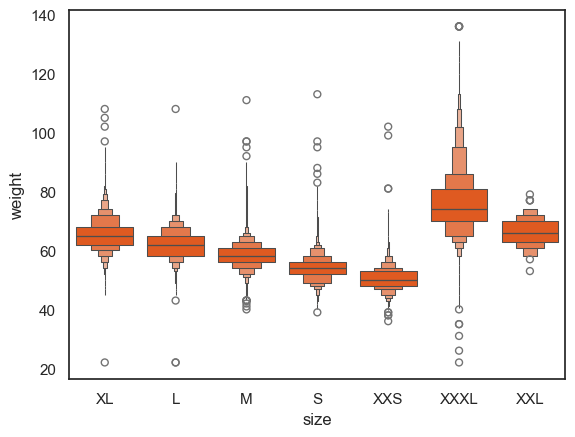

In [6]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.boxenplot(data=df2,x=df2['size'],y=df2['weight'])
plt.savefig('p2.png',dpi=100)
plt.show()

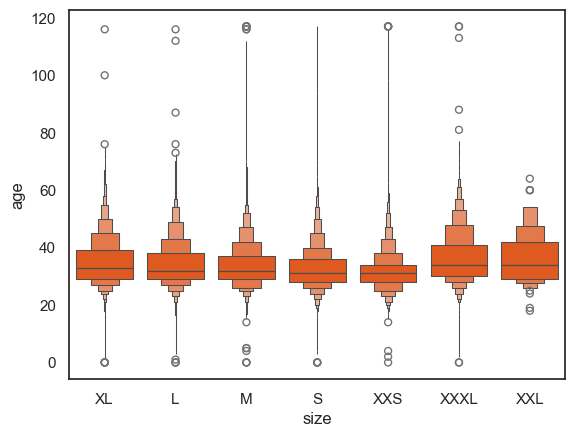

In [7]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.boxenplot(data=df2,x=df2['size'],y=df2['age'])
plt.savefig('p3.png',dpi=100)
plt.show()

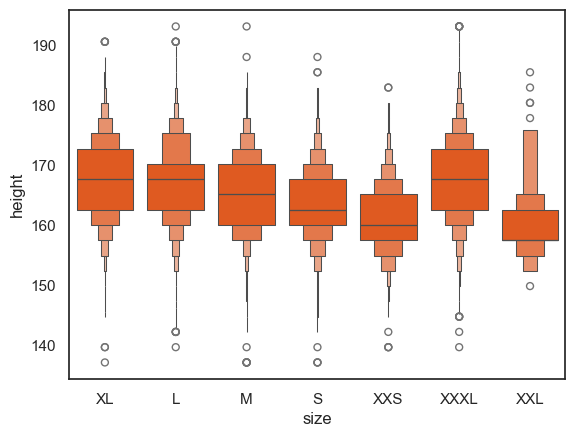

In [8]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.boxenplot(data=df2,x=df2['size'],y=df2['height'])
plt.savefig('p4.png',dpi=100)
plt.show()

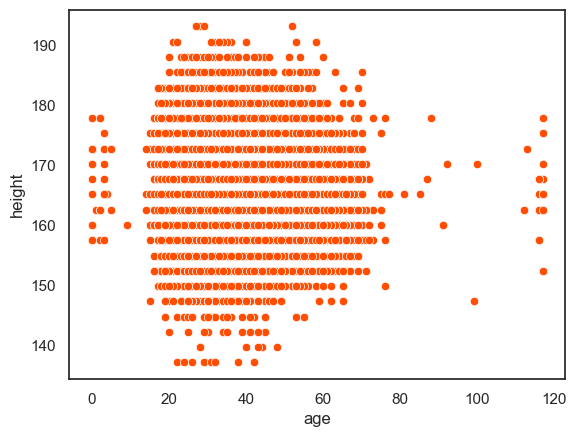

In [9]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.scatterplot(data=df2,x=df2['age'],y=df2['height'])
plt.savefig('p5.png',dpi=100)
plt.show()

In [10]:
print(df2.isna().sum())

weight      0
age       257
height    330
size        0
dtype: int64


In [11]:
simpleImputer=SimpleImputer(strategy='mean')
df2[['age','height']]=simpleImputer.fit_transform(df2[['age','height']])

In [12]:
print(df2.isna().sum())

weight    0
age       0
height    0
size      0
dtype: int64


In [13]:
encoding=LabelEncoder()
df2['size_encoded'] = encoding.fit_transform(df2['size'])

In [14]:
df2['size'].value_counts().to_dict()

{'M': 29712,
 'S': 21924,
 'XXXL': 21359,
 'XL': 19119,
 'L': 17587,
 'XXS': 9964,
 'XXL': 69}

In [71]:
df2[['size','size_encoded']].value_counts().to_dict()

{('M', 1): 29712,
 ('S', 2): 21924,
 ('XXXL', 6): 21359,
 ('XL', 3): 19119,
 ('L', 0): 17587,
 ('XXS', 5): 9964,
 ('XXL', 4): 69}

In [15]:
df2['size_encoded'].value_counts().to_dict()

{1: 29712, 2: 21924, 6: 21359, 3: 19119, 0: 17587, 5: 9964, 4: 69}

In [16]:
df2.sample(10)

,weight,age,height,size,size_encoded
94682,70,38.0,175.26,XL,3
31261,68,29.0,165.10,XL,3
104506,65,24.0,177.80,XL,3
70384,63,35.0,162.56,L,0
109477,60,36.0,167.64,L,0
656,53,35.0,160.02,S,2
75704,72,24.0,175.26,L,0
30896,58,34.0,177.80,M,1
90866,63,28.0,167.64,XL,3
50050,51,38.0,162.56,S,2


In [17]:
df3=pd.DataFrame(data=df2,columns=['age','weight','height','size_encoded'])

In [18]:
df3.sample(10)

,age,weight,height,size_encoded
32539,28.0,54,175.26,5
98731,42.0,60,175.26,1
61294,48.0,56,162.56,1
108380,30.0,65,175.26,3
105706,35.0,56,167.64,1
4451,31.0,64,175.26,2
96111,24.0,51,160.02,2
47150,27.0,70,175.26,0
97450,22.0,54,170.18,2
33226,46.0,70,165.10,6


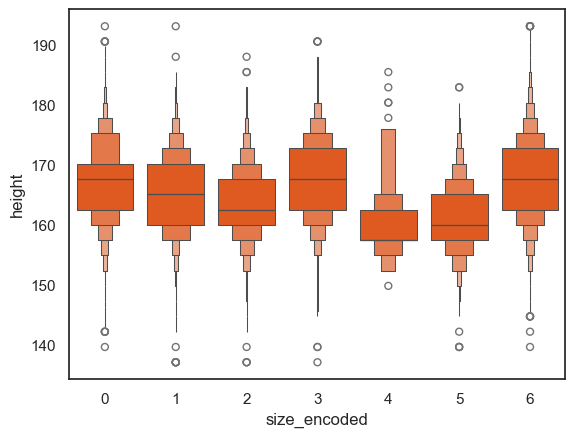

In [19]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.boxenplot(data=df3,x=df3['size_encoded'],y=df3['height'])
plt.savefig('p6.png',dpi=100)
plt.show()

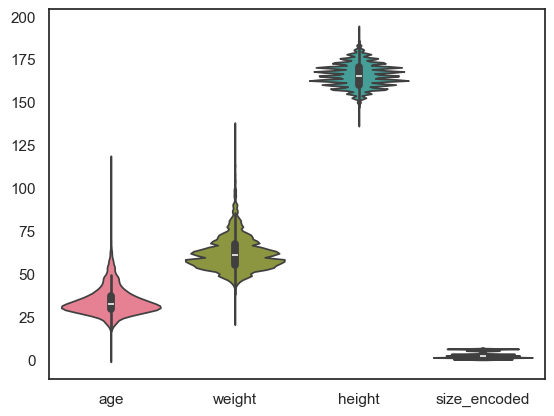

In [20]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.violinplot(df3)
plt.savefig('p7.png',dpi=100)
plt.show()

In [21]:
df3.columns

Index(['age', 'weight', 'height', 'size_encoded'], dtype='object')

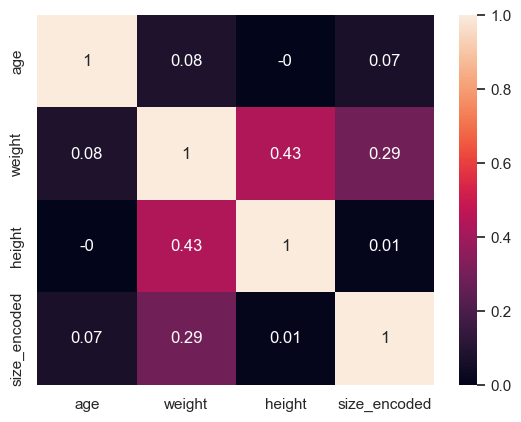

In [22]:
sns.heatmap(df3.corr(method='spearman').round(2),annot=True)
plt.show()

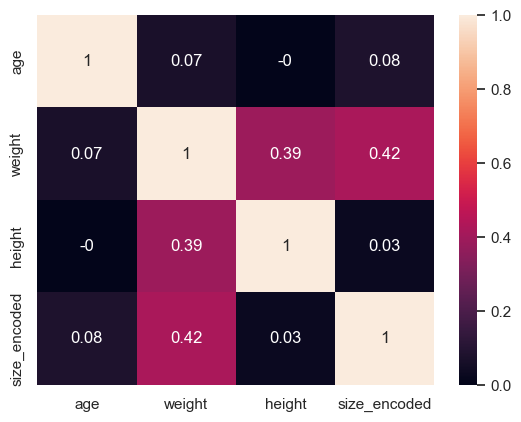

In [23]:
sns.heatmap(df3.corr(method='pearson').round(2),annot=True)
plt.show()

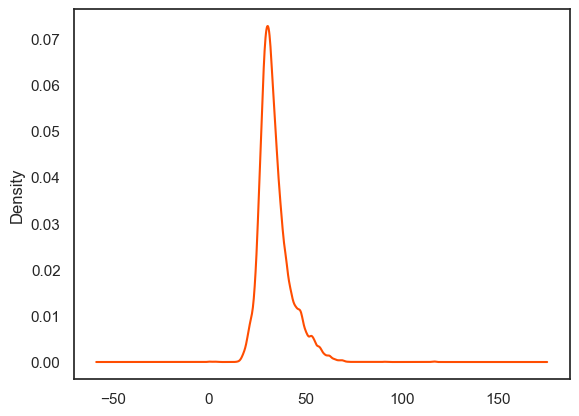

In [24]:
df3['age'].plot(kind='kde')
plt.show()

In [25]:
df3.sample(10)

,age,weight,height,size_encoded
43699,26.0,58,165.10,1
103310,34.0,77,177.80,6
113095,29.0,56,160.02,1
77096,33.0,61,162.56,1
83999,32.0,79,182.88,6
43752,35.0,54,165.10,2
66297,29.0,68,160.02,1
62259,31.0,79,175.26,6
25898,33.0,81,167.64,6
49329,34.0,55,170.18,1


In [26]:
df4=df3.copy()

In [27]:
power_trans=PowerTransformer(method='yeo-johnson')
df4[['age','weight','height']]=power_trans.fit_transform(df4[['age','weight','height']])


In [28]:
df4.sample(10)

,age,weight,height,size_encoded
108417,-0.449910,1.725484,1.382169,6
50479,-0.169786,-1.627617,-1.254702,5
60324,0.704736,-2.009546,-1.663910,1
113373,-0.169786,0.089476,1.027887,2
18712,-0.169786,0.089476,0.297964,0
43024,-0.901712,-0.393866,-0.854221,0
38325,-0.307908,-0.809007,1.382169,5
3678,-0.449910,-0.809007,-0.854221,2
112853,1.038484,-0.526755,-0.462150,1
94477,-0.746535,-1.115491,-1.254702,2


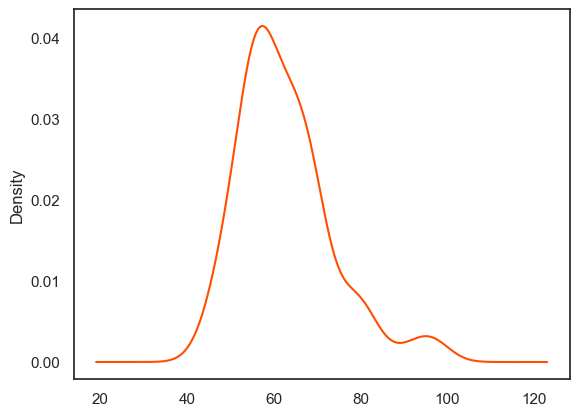

In [29]:
df3['weight'].sample(100).plot(kind='kde')
plt.savefig("p8.png",dpi=100)
plt.show()

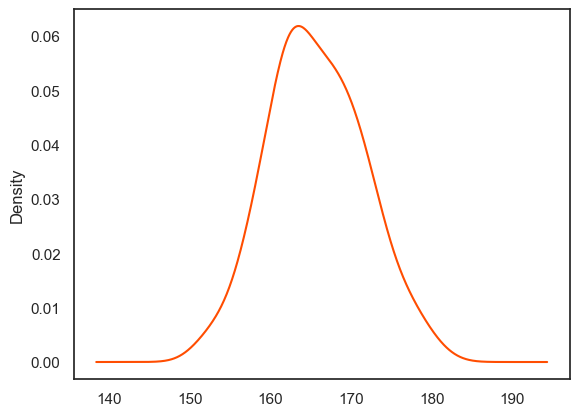

In [30]:
df3['height'].sample(100).plot(kind='kde')
plt.savefig("p9.png",dpi=100)
plt.show()

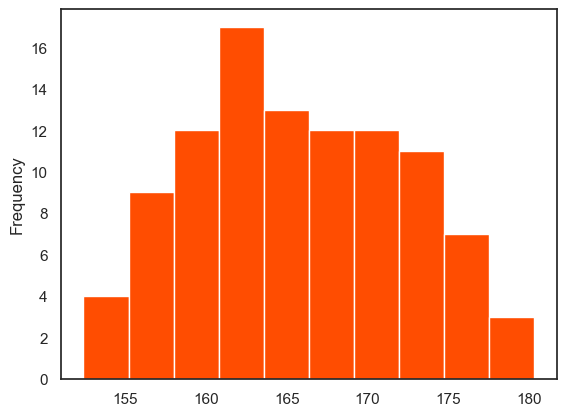

In [31]:
df3['height'].sample(100).plot(kind='hist')
plt.savefig("p10.png",dpi=100)
plt.show()

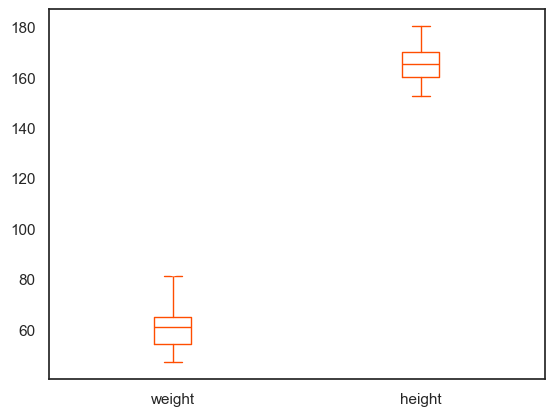

In [32]:
df3[['weight','height']].sample(100).plot(kind='box')
plt.savefig("p11.png",dpi=100)
plt.show()

In [33]:
df4.columns

Index(['age', 'weight', 'height', 'size_encoded'], dtype='object')

In [34]:
df5=pd.DataFrame(data=df3,columns=['age','weight','height','size_encoded']).astype(int)

df5.sample(10)

,age,weight,height,size_encoded
78865,28,65,177,1
14043,33,74,160,6
83863,32,65,170,1
111307,30,56,154,1
114503,31,65,167,0
114519,33,49,162,5
109472,31,56,160,2
12719,34,63,167,0
10130,23,65,175,3
67378,27,62,160,0


In [ ]:
class IQRMethod:
    def __init__(self, data):
        self.data = data
    def anomalies_function(self, column):
        Q1 = self.data[column].quantile(0.25)
        Q3 = self.data[column].quantile(0.75)
        IQR = Q3 - Q1
        left_bound = Q1 - 1.5 * IQR
        right_bound = Q3 + 1.5 * IQR
        anomaly_mask = (self.data[column] < left_bound) | (self.data[column] > right_bound)
        anomaly_indices = self.data[anomaly_mask].index.tolist()
        anomaly_values = self.data[anomaly_mask][column].tolist()     
        return anomaly_indices, anomaly_values

# Get numeric columns
col_numeric = df5.select_dtypes(include='number').columns
print(col_numeric)

IQRmethods_instance = IQRMethod(df5)
all_anomaly_indices = set()

for each_col in col_numeric:
    anomaly_indices, anomaly_values = IQRmethods_instance.anomalies_function(each_col)
    
    if anomaly_indices:
        print(f"Column {each_col}: {len(anomaly_indices)} anomalies found")
        print(f"Indices: {anomaly_indices}")
        all_anomaly_indices.update(anomaly_indices)
    else:
        print(f"Column {each_col}: No anomalies")

print(f"Total unique anomaly indices to remove: {len(all_anomaly_indices)}")

# Remove all anomalies at once
df6 = df5.drop(list(all_anomaly_indices), axis=0)
print(f"Original shape: {df5.shape} and {df5.size}, New shape: {df6.shape} and {df6.size}")

Index(['age', 'weight', 'height', 'size_encoded'], dtype='object')
Column age: 6726 anomalies found
Indices: [6, 22, 40, 76, 80, 92, 97, 117, 126, 130, 158, 161, 163, 172, 180, 192, 205, 214, 252, 256, 266, 283, 303, 374, 378, 390, 417, 422, 427, 441, 451, 502, 516, 533, 538, 591, 618, 643, 652, 672, 703, 736, 756, 761, 796, 799, 856, 872, 898, 902, 922, 994, 1014, 1022, 1053, 1065, 1097, 1122, 1134, 1139, 1150, 1152, 1165, 1228, 1239, 1246, 1257, 1261, 1288, 1290, 1303, 1309, 1310, 1325, 1340, 1357, 1358, 1376, 1388, 1391, 1399, 1402, 1507, 1508, 1512, 1521, 1528, 1529, 1563, 1576, 1594, 1659, 1661, 1672, 1676, 1699, 1706, 1708, 1722, 1744, 1778, 1780, 1786, 1787, 1802, 1824, 1830, 1839, 1843, 1880, 1905, 1906, 1919, 1921, 1943, 1965, 2020, 2026, 2034, 2039, 2048, 2066, 2071, 2095, 2129, 2138, 2140, 2141, 2175, 2208, 2222, 2231, 2255, 2275, 2281, 2307, 2320, 2391, 2407, 2418, 2426, 2428, 2461, 2493, 2515, 2542, 2543, 2549, 2573, 2576, 2627, 2659, 2681, 2690, 2723, 2726, 2736, 2745, 27

In [36]:
# class AnomoliesClass:
#     def __init__(self,data):
#         self.data=data
#         pass 
#     def anomolies_func(self,col):
#         mean_values=sts.mean(self.data[col])
#         std_value=sts.stdev(self.data[col])
#         cutoff=3*std_value
#         lower_bound=mean_values-cutoff
#         upper_bound=mean_values+cutoff
        
#         mask=(self.data[col] < lower_bound) | (self.data[col]> upper_bound)
#         anomolies_ind=self.data[mask].index.tolist()
#         anomolies_values=self.data[mask][col].tolist()
        
#         return anomolies_ind,anomolies_values
    
# AnomoliesClass_instance =AnomoliesClass(df5)
# seeting_anomolies_i1=set()
# for each_column in col_numeric:
#     anomolies_indi, anomolies_values=AnomoliesClass_instance.anomolies_func(each_column)
#     if anomolies_indi:
#         print(f"each columsn {each_column} and values {anomolies_values} and \n {len(anomolies_indi)}")
#         seeting_anomolies_i1.update(anomolies_indi)
#         print(seeting_anomolies_i1)
#     else:
#         print(f"{each_column} no anomolies")
               
# df7=df5.drop(list(seeting_anomolies_i1),axis=0)
# print(f"new shape is {df7.shape} and old shape is {df5.shape}")

In [37]:
x1=df4[['age','weight','height']]
y1=df4['size_encoded']

In [38]:
features_selection=SelectKBest(score_func=f_classif,k=2)
results=features_selection.fit_transform(x1,y1)
get_col=x1.columns[features_selection.get_support()]
get_col
    

Index(['weight', 'height'], dtype='object')

In [39]:
df6.shape[0]

109605

In [40]:
x=df6.drop(columns=['size_encoded'])
y=df6['size_encoded'].squeeze()

In [41]:
x.shape[0]

109605

In [42]:
y.shape[0]

109605

In [43]:
logistic_regression=LogisticRegression(solver='lbfgs')
logistic_regression

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [44]:
import warnings

warnings.filterwarnings("ignore")

In [45]:
# 1. Outlier removal → df6 (you already did this)

# 2. Extract X and y from df6
x = df6.drop(columns=['size_encoded'])
y = df6['size_encoded'].squeeze()  # Ensure 1D

# 3. Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# 4. Validate
assert x_train.shape[0] == y_train.shape[0], "Mismatch after split!"

# 5. Fit
logistic_regression.fit(x_train, y_train)  # ✅ Should work now

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [46]:
x.columns

Index(['age', 'weight', 'height'], dtype='object')

In [69]:
x.describe()

,age,weight,height
count,109605.000000,109605.000000,109605.000000
mean,32.745669,60.724775,165.281192
std,6.144065,8.113507,6.640533
min,17.000000,38.000000,147.000000
25%,29.000000,55.000000,160.000000
50%,32.000000,60.000000,165.000000
75%,36.000000,65.000000,170.000000
max,49.000000,85.000000,185.000000


In [47]:
logistic_regression.fit(x_train, y_train) 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [48]:
print(f'''
      {x.shape}
      {y.shape}
      {x_train.shape[0]}
      {y_train.shape[0]}
      ''')


      (109605, 3)
      (109605,)
      87684
      87684
      


In [49]:
assert x_train.shape[0] == y_train.shape[0], "Mismatch in samples!"

In [50]:
logistic_regression.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [51]:
import warnings
warnings.filterwarnings("ignore")

In [52]:
logistic_score=cross_val_score(logistic_regression,x,y,scoring='accuracy',cv=10)
logistic_score

array([0.47167229, 0.47760241, 0.47951829, 0.47824104, 0.47285832,
       0.47919708, 0.47819343, 0.48138686, 0.47636861, 0.48038321])

In [53]:
Decesion_tree_classi=DecisionTreeClassifier(criterion='entropy',max_depth=8,min_samples_split=20,min_samples_leaf=10,splitter='best')
Decesion_tree_classi

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cur

In [54]:
Decesion_tree_classi.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cur

In [55]:
decesion_score=cross_val_score(Decesion_tree_classi,x,y,scoring='accuracy',cv=10,n_jobs=-1)
mean_value=np.mean(decesion_score)
print(mean_value)

0.49978554190470936


In [56]:
random_tree_classi=RandomForestClassifier(n_estimators=100,n_jobs=-1,criterion='entropy',max_depth=8,min_samples_split=20,min_samples_leaf=10,max_features='sqrt')
random_tree_classi

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [57]:
random_tree_classi.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [58]:
y_random=random_tree_classi.predict(x_test)
y_random

array([3, 1, 5, ..., 1, 1, 1], shape=(21921,))

In [59]:
y_decesion=Decesion_tree_classi.predict(x_test)
y_decesion

array([3, 1, 5, ..., 1, 1, 1], shape=(21921,))

In [60]:
y_logistic=logistic_regression.predict(x_test)
y_logistic

array([3, 1, 5, ..., 1, 1, 1], shape=(21921,))

In [61]:
joblib.dump(logistic_regression,"logistic_regression.joblib")

['logistic_regression.joblib']

In [72]:
joblib.dump(Decesion_tree_classi,"Decesion_tree_classi.joblib")

['Decesion_tree_classi.joblib']

In [73]:
joblib.dump(random_tree_classi,"random_tree_classi.joblib")

['random_tree_classi.joblib']

In [64]:



print(logistic_regression.score(x_test,y_logistic))
print(Decesion_tree_classi.score(x_test,y_decesion))
print(random_tree_classi.score(x_test,y_random))


1.0
1.0
1.0


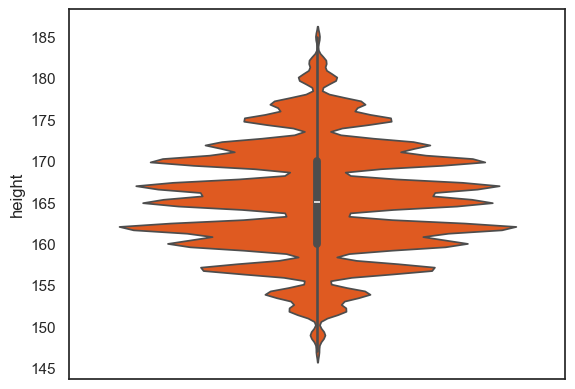

In [65]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
sns.violinplot(df6['height'])
plt.savefig("p13.png",dpi=100)
plt.show()

In [66]:
x.columns

Index(['age', 'weight', 'height'], dtype='object')